## Best Lambda Value CV

In [1]:
from Pipeline.Algorithm.ArtificialBeeColonyElmCV import ArtificialBeeColonyElmCV
from Pipeline.Global.GallstoneDataSet import GallstoneDataSet
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Global.Plotting import Plotting
from Pipeline.Optimization.ABC_Testing import abc_testing

In [2]:
gallstone_dataset = GallstoneDataSet()
gallstone_dataset.fetch_data_path_1()

features_size = gallstone_dataset.x_train.shape[1]
x_train = gallstone_dataset.x_train
x_test  = gallstone_dataset.x_test
y_train = gallstone_dataset.y_train
y_test  = gallstone_dataset.y_test

In [3]:
mod = "Best_Lambda"

In [4]:
best_lambda_config = GlobalSetting.get_config_by_type(mod)
best_lamda_hidden_size = best_lambda_config["Hidden_Nodes"] if best_lambda_config else None
best_lamda_lambda_value = best_lambda_config["Lambda_Value"] if best_lambda_config else None

In [5]:
abc_elm_cv_hidden  = ArtificialBeeColonyElmCV(
    features_size       = features_size,
    hidden_size         = best_lamda_hidden_size,
    activation_function = GlobalSetting.sigmoid             ,
    regularization_lambda=best_lamda_lambda_value           ,
    fitness_function    = GlobalSetting.evaluation_function ,
    solution_size       = GlobalSetting.solution_size       ,
    trial_limit         = GlobalSetting.trial_limit         ,
    max_iteration       = GlobalSetting.max_iteration
)

In [6]:
results_df , convergence_df , scout_df = abc_testing(abc_elm_cv_hidden, x_train, y_train, x_test, y_test)
results_df.describe()

Seed 41 start

Iteration 1 end : 0.0580s | Scout Triggers: 0
Iteration 2 end : 0.0831s | Scout Triggers: 0
Iteration 3 end : 0.0975s | Scout Triggers: 0
Iteration 4 end : 0.1210s | Scout Triggers: 0
Iteration 5 end : 0.1006s | Scout Triggers: 0
Iteration 6 end : 0.0954s | Scout Triggers: 0
Iteration 7 end : 0.1386s | Scout Triggers: 0
Iteration 8 end : 0.1017s | Scout Triggers: 0
Iteration 9 end : 0.0843s | Scout Triggers: 0
Iteration 10 end : 0.0917s | Scout Triggers: 0
Iteration 11 end : 0.0790s | Scout Triggers: 0
Iteration 12 end : 0.0886s | Scout Triggers: 0
Iteration 13 end : 0.0848s | Scout Triggers: 0
Iteration 14 end : 0.0800s | Scout Triggers: 1
Iteration 15 end : 0.0859s | Scout Triggers: 2
Iteration 16 end : 0.0741s | Scout Triggers: 0
Iteration 17 end : 0.2013s | Scout Triggers: 0
Iteration 18 end : 0.1149s | Scout Triggers: 1
Iteration 19 end : 0.0906s | Scout Triggers: 1
Iteration 20 end : 0.0803s | Scout Triggers: 0
Iteration 21 end : 0.0629s | Scout Triggers: 0
Iterati

,Accuracy,Precision,Recall,NPV,Specificity,F1-Score,F2-Score,Bal Accuracy,MCC,ABC_Seed
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.782292,0.798017,0.758333,0.773379,0.806250,0.775557,0.764662,0.782292,0.567964,55.500000
std,0.029854,0.029605,0.071040,0.050553,0.042167,0.037441,0.057168,0.029854,0.059190,8.803408
min,0.734375,0.741935,0.625000,0.700000,0.718750,0.714286,0.657895,0.734375,0.468979,41.000000
25%,0.765625,0.781883,0.718750,0.738346,0.781250,0.754098,0.725574,0.765625,0.531510,48.250000
50%,0.773438,0.796552,0.750000,0.761141,0.812500,0.767949,0.757105,0.773438,0.550178,55.500000
75%,0.796875,0.818182,0.804688,0.803368,0.843750,0.804839,0.803375,0.796875,0.599360,62.750000
max,0.859375,0.846154,0.906250,0.896552,0.875000,0.865672,0.889571,0.859375,0.721930,70.000000


[I/O Trace] Figure exported successfully: ../../Storage/Figure\ABC_Telemetry_Best_Lambda_CV_F1-Score.png


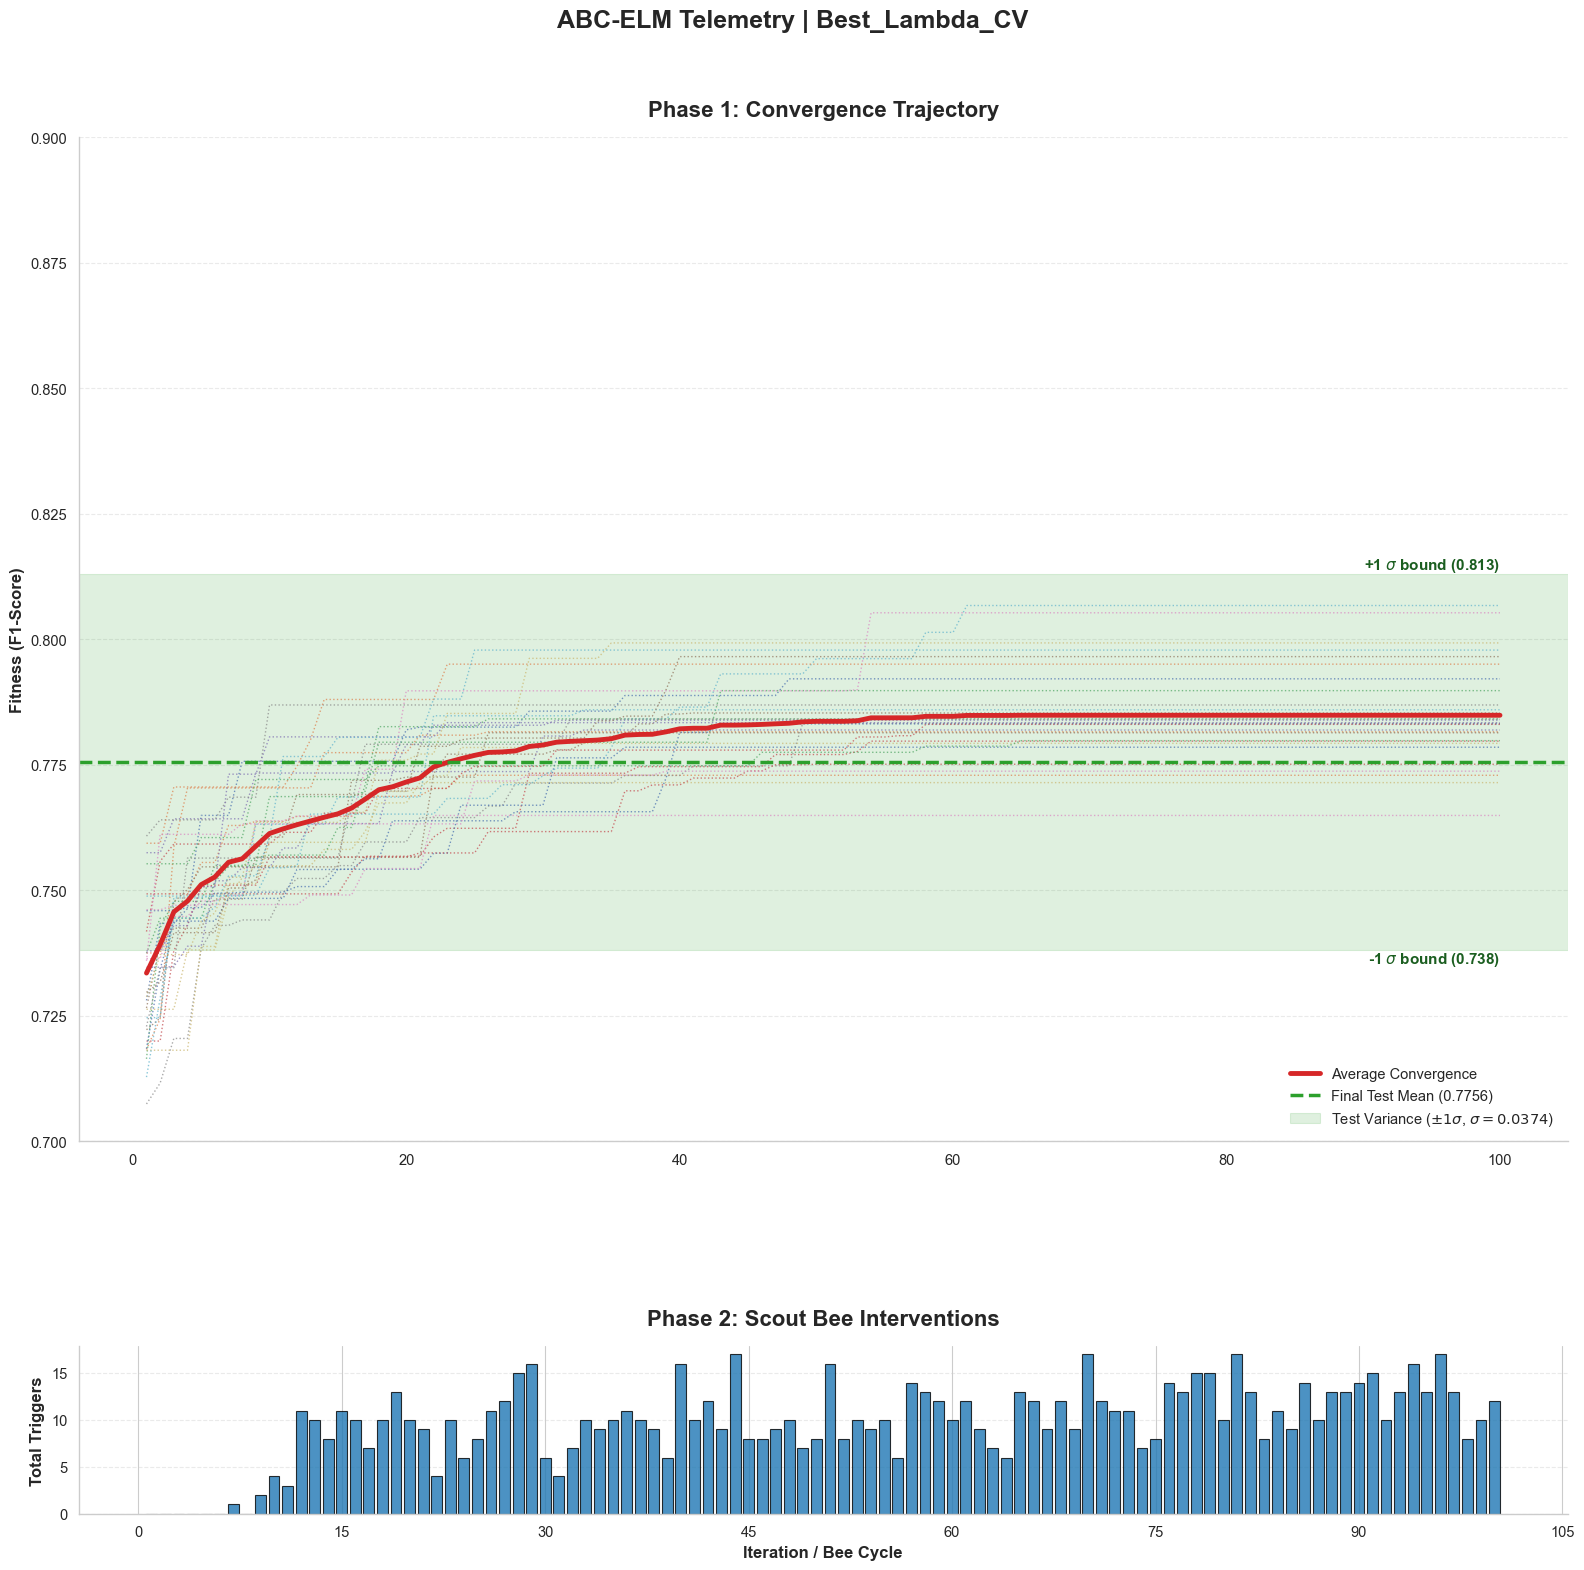

In [7]:
Plotting.plot_abc_dashboard(convergence_df,scout_df,f"{mod}_CV",results_df,is_final_record=True)

In [8]:
GlobalSetting.save_dataframe_to_record(results_df, f"ABC_{mod}_Results.csv")

GlobalSetting.save_dataframe_to_record(convergence_df, f'ABC_{mod}_Convergence.csv')

GlobalSetting.save_dataframe_to_record(scout_df, f'ABC_{mod}_Scout_History.csv')

[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Best_Lambda_Results.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Best_Lambda_Convergence.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Best_Lambda_Scout_History.csv
